# Electrochemical impedance spectroscopy (EIS) simulation

Electrochemical impedance spectroscopy (EIS) is an important test performed on solid oxide cells to identify the sources of cell resistance.

Therefore, simulating the same test in a virtual environment can be an useful tool for validation and fitting models for new cells and materials.

The nest-soc provides some pre-builded routines to perform such analysis, which can be combined with optimization algorithms for fitting and calibration of new cell/layer models and degradation.

## The basic model

Let's start from a simple model similar to the one that we developed in the [first tutorial](1_basics.ipynb).

In [10]:
# 1. Importing packages
from nest import properties, layers, cell

# 2. Define Species and Mixture
fuel_mix = properties.Mixture((properties.BasicSpecies.H2, properties.BasicSpecies.H2O))
air_mix = properties.Mixture((properties.BasicSpecies.O2))

# 3. Define cell Layers with their properties (kinetic, transport, conductivity, etc.)
Ni_YSZ = layers.Layer(
    delta=3e-4 + 10e-6,
    kinetic=layers.ButlerVolmer(
        gas=fuel_mix,
        alpha=0.59,
        beta=1 - 0.59,
        gamma=0.56 * 1.82527e6,
        theta=1,
        nu=[-1, 1],
        E_act=1.09 / 8.617333262e-5 * 8.314510,
        p=[-0.1, 0.33],
        n_e=2,
    ),
    transport=layers.StefanMaxwell(dp=6e-7, epsilon=0.3, tau=7),
)
YSZ = layers.Layer(
    delta=12e-6 - 2e-6,
    conductivity=layers.Conductivity(
        sigma0=3.6e7,
        E_act=8e4,
    ),
)
YSZ_CGO = layers.Layer(
    delta=4e-6,
    conductivity=layers.Conductivity(sigma0=1715, E_act=8785 * 8.314510, theta=0),
)
CGO = layers.Layer(
    delta=10e-6 - 2e-6,
    conductivity=layers.Conductivity(
        sigma0=1.09e7,
        E_act=0.64 / 8.617333262e-5 * 8.314510,
    ),
)
LSCF_CGO = layers.Layer(
    delta=3e-5,
    kinetic=layers.ButlerVolmer(
        gas=air_mix,
        alpha=0.65,
        beta=1 - 0.65,
        gamma=1.51556e8,
        nu=[-0.5],
        E_act=1.45 / 8.617333262e-5 * 8.314510,
        p=[0.22],
    ),
    transport=layers.StefanMaxwell(dp=6e-7, epsilon=0.3, tau=2.8),
)

# 4. Define cell from the Layers
cellObject = cell.Cell(16e-4, Ni_YSZ, (YSZ, YSZ_CGO, CGO), LSCF_CGO)

# 5. Define boundary conditions
n_fuel_total = (24 / 1e3 / 3600) * (1e5 / 8.314510 / 273.15)  # mol/s
n_air_total = 50 / 1e3 / 3600 * (1e5 / 8.314510 / 273.15)  # mol/s
x_H2 = 0.5
x_O2 = 1
boundaryObject = cell.BoundaryData(
    V=1.25,
    j=-0.5e4,
    n_fuel=[n_fuel_total * x_H2, n_fuel_total * (1 - x_H2)],
    n_air=[n_air_total * x_O2],
    T=757 + 273.15,
    P=1e5,
)

# 5. Solve for voltage (just a check)
solution = cellObject.solve_for_voltage(boundaryObject)
print(f"The average current density is {solution[1].mean()} A/cm2")

The average current density is -6868.0062423029185 A/cm2


## Adapting the model for the EIS simulation

In order to simulate the impedance of the cell, some extra information and adjustments are required:

1. Include effective capacitances for each electrode layer in their **kinetic** model
2. Adjust the number of elements that each electrode **Layer** should be discretized in the thickness direction
3. Adjust the number of elements that the **Cell** should be discretized in the conversion direction
4. Adjust the flow channel height in the **Cell** object

### Including effective capacitances

The effective capacitances are a simplified approach to model the capacity of electrodes to store charges/ions.

During very fast changes of voltage, these capacitances alter the current response from the expected values on steady-state.

In mathematical terms, nest-soc solves the following differential equation, which is based on an equivalent circuit model:

$$ C_i \frac{d\eta_{act,i}}{dt} + j_{bv,i} = j $$

In which,
* $C_i$ : equivalent capacitance for electrode i [F/m^2]
* $\eta_{act,i}$ : activation overpotential of electrode i [V]
* $t$ : time [s]
* $j_{bv}$ : current density calculated from the Butler-Volmer equation for electrode i [A/cm^2]
* $j$ : current density [A/cm^2]

The capacitances can be simply included as an attribute on the kinetic model for each electrode:

In [11]:
# Equivalent capacitance for fuel electrode
Ni_YSZ.kinetic.C = 1.1 * 2.7
# Equivalent capacitance for air electrode
LSCF_CGO.kinetic.C = 110 * 2

### Adjusting discretization on the electrodes and cell

Behind the scenes, the nest-soc package will solve the electrodes in a 2D grid.

This is necessary to account for the mass transfer processes involved in the cell.

Similarly to the electric capacitances, the mass transport phenomena (i.e., diffusion and advection) will cause a capacitance effect on the partial pressures affecting the current.

This can be done by adjusting the attribute elements in the layers and in the cell:

In [12]:
# Adjusting discretization in the thickness direction
Ni_YSZ.elements = 5
LSCF_CGO.elements = 2

# Adjusting discretization in the conversion direction
cellObject = cell.Cell(16e-4, Ni_YSZ, (YSZ, YSZ_CGO, CGO), LSCF_CGO, elements=5)

**Note** : the minimal number of elements on a layer should be 2

### Adjusting the channel height

Finally, the volume of species in the gas channels is dependent on the height of the channel.

This can significantly change the partial pressure of species during the EIS simulation.

The channel height can be adjusted as an attribute on the **Cell** object:

In [13]:
cellObject.delta_channel = 0.6 * 1e-3

### (Optional) Setting the cell voltage on OCV

Since most of the EIS experiments are done on OCV conditions, one may also like to set up the simulations on the same conditions.

The OCV voltage can be calculated from the **Cell** object using the method **V_nernst**:


In [14]:
# Calculating OCV voltage
V_nernst = cellObject.V_nernst(
    boundaryObject.T, boundaryObject.Ps_fuel(), boundaryObject.Ps_air()
)

# Fixing OCV voltage to boundary conditions
boundaryObject.V = V_nernst

## Solving and plotting results

Once the model has been set up, the EIS simulation can be run by simply calling the **eis** function from the **eis** subpackage:

In [15]:
from nest import eis

f, Z = eis.eis(cellObject, boundaryObject)


   message: Reached specified tstop.
   success: True
    status: 1
         t: [ 0.000e+00  3.125e-04 ...  3.384e+00  5.000e+00]
         y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
             [ 7.856e-17  7.856e-17 ...  2.105e-17  2.105e-17]
             ...
             [ 3.226e-04  3.128e-04 ...  7.173e-05  6.954e-05]
             [ 3.226e-04  3.128e-04 ...  7.173e-05  6.954e-05]]
        yp: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
             [ 2.514e-13  2.514e-13 ...  6.737e-14  6.737e-14]
             ...
             [-9.255e-18  9.230e-18 ...  5.192e-18  5.412e-17]
             [ 1.746e-17  7.888e-18 ...  1.052e-18 -4.116e-18]]
  i_events: None
  t_events: None
  y_events: None
 yp_events: None
      nfev: 381
      njev: 77



The eis function returns two results:
* f: the frequencies [Hz]
* Z: an array of impedance objects holding both the real and imaginary parts [Ohm.cm^2] 

Plotting and comparing with experimental data:

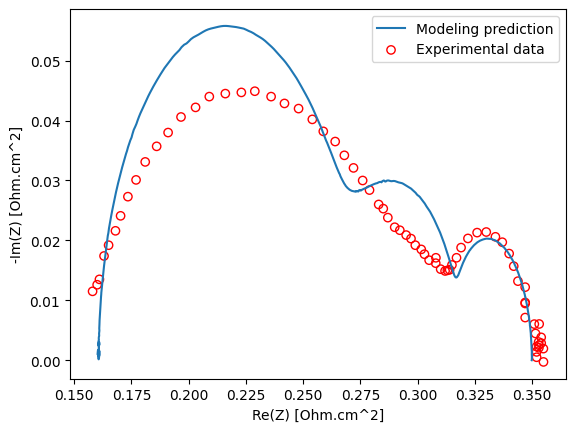

In [16]:
# 1. Import packages
import matplotlib.pyplot as plt
import pandas as pd

# 2. Extract real and imaginary parts from solution
Z_real = [z.real for z in Z]
Z_imag = [-z.imag for z in Z]

# 3. Plot both the simulation and the experimental data
plt.plot(Z_real, Z_imag, label="Modeling prediction")
data = pd.read_csv("../data/757C_50H2_100O2_EIS.csv")
plt.scatter(
    data["real"] * 1e4,
    data["imag"] * 1e4,
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
plt.xlabel("Re(Z) [Ohm.cm^2]")
plt.ylabel("-Im(Z) [Ohm.cm^2]")
plt.legend()
plt.show()

Plotting the imaginary and real part separately:

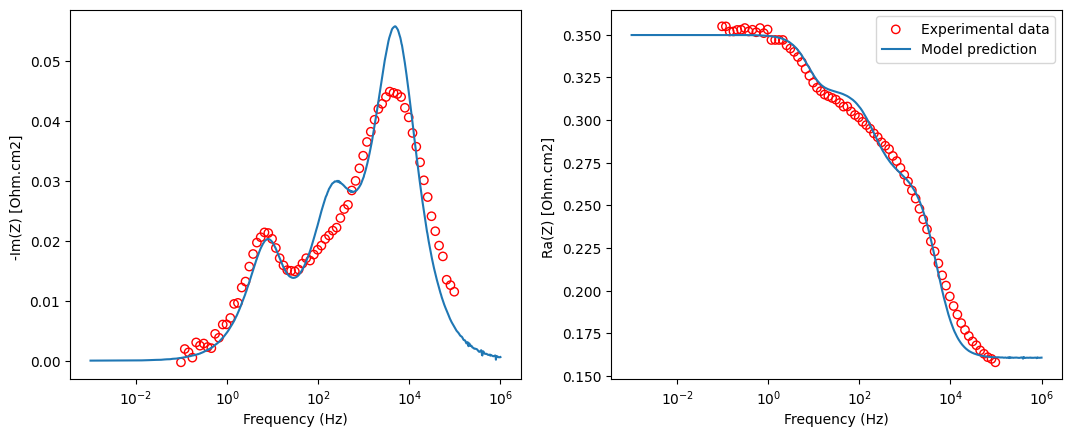

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.4 * 2, 4.8))

ax1.scatter(
    data["f"],
    data["imag"] * 1e4,
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
ax1.set_xscale("log")

ax2.scatter(
    data["f"],
    data["real"] * 1e4,
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
ax2.set_xscale("log")

ax1.plot(f, Z_imag, label="Model prediction")
ax2.plot(f, Z_real, label="Model prediction")

ax1.set_xlabel("Frequency (Hz)")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("-Im(Z) [Ohm.cm2] ")
ax2.set_ylabel("Ra(Z) [Ohm.cm2] ")

plt.legend()
plt.show()